# Visual Inspection PoC — PatchCore Anomaly Detection

**Goal:** For each of the 4 part types (`bottle`, `screw`, `tile`, `toothbrush`), train a
**single-class** model that learns *only* what a **good** part looks like and flags anything that
deviates as a **defect** — without ever being told which specific defect it is.

## Why PatchCore (and not a pixel autoencoder)

A pixel-reconstruction autoencoder assumes the part is **aligned** — it learns "what value is normal
at pixel (x, y)". That fails on parts with **no fixed orientation** like `screw`, which appear at
arbitrary rotations and positions: the model is forced to treat every orientation as normal, so it
either blurs (false alarms) or over-generalises (misses defects).

**PatchCore** removes that assumption. It works on **local patches** of deep features instead of raw
pixels:
1. A frozen ImageNet-pretrained **ResNet-18** turns each image into a grid of **local patch features**
   (mid-level blocks `layer2` + `layer3`).
2. All patch features from every *good* training image go into a **memory bank**, compressed with a
   **greedy coreset** (keep a representative subset).
3. A test patch is scored by its **distance to the nearest good patch** in the bank. The image score
   is the **worst (max) patch**. Far from anything good ⇒ defect.

Because scoring is **patch-local nearest-neighbour**, a rotated good screw's patches still match good
patches elsewhere in the bank — **orientation no longer needs to be fixed**. As a bonus we get a
**heatmap** showing *where* the anomaly is.


## 0. Setup & configuration

In [1]:
import shutil
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.feature_extraction import create_feature_extractor
from torchvision import transforms
from sklearn.metrics import roc_auc_score, precision_score, recall_score

ROOT = Path.cwd()                       # the "CV POC" folder
PARTS = ["bottle", "screw", "tile", "toothbrush"]
MODEL_DIR = ROOT / "models"
MODEL_DIR.mkdir(exist_ok=True)

DEVICE = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

# PatchCore hyper-parameters
IMG_SIZE   = 256      # resize, then center-crop
CROP_SIZE  = 224
CORESET_RATIO = 0.10  # keep 10% of patches in the memory bank
POOL_MAX      = 60000 # cap candidate patches before coreset (bounds runtime)
CORESET_MAX   = 4000  # hard cap on final bank size per part

print("Working dir :", ROOT)
print("Parts       :", PARTS)
print("Device      :", DEVICE)

Working dir : /Users/hemcharanvarma/Desktop/CV POC
Parts       : ['bottle', 'screw', 'tile', 'toothbrush']
Device      : mps


## 1. Arrange folders into `train` / `test` only

We reshape every part into a simple layout — no defect-type subfolders, no ground-truth masks —
because our use case only cares about good vs. not-good:

```
<part>/
├── train/good/       # good images only  → build the memory bank
└── test/
    ├── good/         # good test images
    └── defect/       # ALL defect types merged → evaluation
```

The merge keeps the original defect name as a filename **prefix** (e.g. `broken_large_000.png`),
so nothing is lost — it's just flattened. This cell is **idempotent** (safe to re-run).

In [2]:
def arrange_part(part: str) -> dict:
    base = ROOT / part
    test_dir = base / "test"
    defect_dir = test_dir / "defect"

    for sub in sorted(test_dir.iterdir()):
        if not sub.is_dir() or sub.name in ("good", "defect"):
            continue
        defect_dir.mkdir(exist_ok=True)
        for img in sorted(sub.glob("*.png")):
            img.rename(defect_dir / f"{sub.name}_{img.name}")  # keep defect name in filename
        sub.rmdir()

    gt = base / "ground_truth"
    if gt.exists():
        shutil.rmtree(gt)

    return {
        "train/good":  len(list((base / "train" / "good").glob("*.png"))),
        "test/good":   len(list((test_dir / "good").glob("*.png"))),
        "test/defect": len(list(defect_dir.glob("*.png"))) if defect_dir.exists() else 0,
    }

print(f"{'part':<12}{'train/good':>12}{'test/good':>12}{'test/defect':>14}")
for p in PARTS:
    c = arrange_part(p)
    print(f"{p:<12}{c['train/good']:>12}{c['test/good']:>12}{c['test/defect']:>14}")

part          train/good   test/good   test/defect
bottle               209          20            63
screw                320          41           119
tile                 230          33            84
toothbrush            60          12            30


## 2. Patch feature extractor

We tap `layer2` and `layer3` of a frozen ResNet-18. `layer3` is upsampled to `layer2`'s resolution
and concatenated, giving one feature vector **per spatial location** (a 28×28 grid ⇒ 784 patches per
image, each 384-dim). A 3×3 average pool makes each patch aggregate its local neighbourhood — the
standard PatchCore "locally aware" patch. **No weights are trained.**

In [3]:
_weights = ResNet18_Weights.IMAGENET1K_V1
_backbone = resnet18(weights=_weights)
FEATURE_NODES = ["layer2", "layer3"]
_extractor = create_feature_extractor(_backbone, return_nodes=FEATURE_NODES).eval().to(DEVICE)
for p in _extractor.parameters():
    p.requires_grad_(False)

preprocess = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

@torch.no_grad()
def patch_features(paths, batch_size=16, return_grid=False):
    """Return patch features. If return_grid: list of (H, W, C) per image; else stacked (N*H*W, C)."""
    per_image, grid_hw = [], None
    for i in range(0, len(paths), batch_size):
        batch = [preprocess(Image.open(p).convert("RGB")) for p in paths[i:i + batch_size]]
        x = torch.stack(batch).to(DEVICE)
        feats = _extractor(x)
        f2, f3 = feats["layer2"], feats["layer3"]
        f3 = F.interpolate(f3, size=f2.shape[-2:], mode="bilinear", align_corners=False)
        f2 = F.avg_pool2d(f2, 3, 1, 1)          # locally-aware patch
        f3 = F.avg_pool2d(f3, 3, 1, 1)
        emb = torch.cat([f2, f3], dim=1)         # (B, 384, H, W)
        grid_hw = emb.shape[-2:]
        emb = emb.permute(0, 2, 3, 1).reshape(emb.shape[0], -1, emb.shape[1])  # (B, H*W, C)
        per_image.append(emb.cpu())
    per_image = torch.cat(per_image)             # (N, H*W, C)
    if return_grid:
        H, W = grid_hw
        return [img.reshape(H, W, -1).numpy() for img in per_image], grid_hw
    return per_image.reshape(-1, per_image.shape[-1]).numpy(), grid_hw

def list_images(folder):
    return sorted(Path(folder).glob("*.png"))

_probe, _hw = patch_features(list_images(ROOT / "bottle" / "train" / "good")[:1])
print(f"Patch grid = {_hw[0]}x{_hw[1]} = {_hw[0]*_hw[1]} patches/image | patch dim = {_probe.shape[1]}")

Patch grid = 28x28 = 784 patches/image | patch dim = 384


## 3. Greedy coreset subsampling

A full memory bank (every patch of every good image) is large and slow to search. PatchCore keeps a
**coreset**: greedily pick patches that are maximally spread out (a k-center / furthest-point
selection), so the subset still covers the space of "normal" patches. We project to a lower dimension
for a fast distance computation, exactly as in the paper.

In [4]:
def greedy_coreset(feats, ratio=CORESET_RATIO, pool_max=POOL_MAX, size_max=CORESET_MAX, proj_dim=128):
    """Greedy k-center coreset. Returns a subset of `feats` (np.ndarray)."""
    n = feats.shape[0]
    # pre-subsample huge banks so the greedy loop stays fast
    if n > pool_max:
        keep = np.random.choice(n, pool_max, replace=False)
        feats = feats[keep]
        n = pool_max
    m = min(int(n * ratio), size_max)

    f = torch.from_numpy(feats).to(DEVICE)
    proj = torch.randn(f.shape[1], proj_dim, device=DEVICE) / (proj_dim ** 0.5)
    fp = f @ proj                                   # random projection

    selected = torch.zeros(m, dtype=torch.long, device=DEVICE)
    min_dist = torch.full((n,), float("inf"), device=DEVICE)
    last = torch.randint(0, n, (1,), device=DEVICE).item()
    for i in range(m):
        selected[i] = last
        d = ((fp - fp[last]) ** 2).sum(1)
        min_dist = torch.minimum(min_dist, d)
        min_dist[last] = -1.0                       # never reselect
        last = int(torch.argmax(min_dist).item())
    return feats[selected.cpu().numpy()]

print("greedy_coreset ready.")

greedy_coreset ready.


## 4. Train the 4 PatchCore models

For each part: collect patch features from all `train/good` images → coreset → that's the memory bank
(saved to `models/<part>_patchcore.npy`). One independent model per part (4 total). We also record the
image-level score of each *good training* image to set a threshold later.

In [5]:
@torch.no_grad()
def image_scores(bank_t, paths, grid=False):
    """Max patch-to-bank nearest-neighbour distance per image (PatchCore image score).
    If grid=True also return per-patch distance maps for heatmaps."""
    scores, maps = [], []
    per_img, hw = patch_features(paths, return_grid=True)
    for g in per_img:
        H, W, C = g.shape
        q = torch.from_numpy(g.reshape(-1, C)).to(DEVICE)          # (H*W, C)
        d = torch.cdist(q, bank_t)                                 # (H*W, N_bank)
        nn = d.min(dim=1).values                                  # nearest good patch
        scores.append(nn.max().item())
        if grid:
            maps.append(nn.reshape(H, W).cpu().numpy())
    return (np.array(scores), maps) if grid else np.array(scores)

models = {}
for part in PARTS:
    good_paths = list_images(ROOT / part / "train" / "good")
    feats, _ = patch_features(good_paths)                          # (N*784, 384)
    bank = greedy_coreset(feats)                                   # coreset subset
    bank_t = torch.from_numpy(bank).to(DEVICE)

    train_scores = image_scores(bank_t, good_paths)               # good-only scores -> threshold
    np.save(MODEL_DIR / f"{part}_patchcore.npy", bank)
    models[part] = {"bank_t": bank_t, "train_scores": train_scores}
    print(f"{part:<12} {len(good_paths):>3} good imgs | patches {feats.shape[0]:>7} -> "
          f"bank {bank.shape[0]:>4} | saved models/{part}_patchcore.npy")

bottle       209 good imgs | patches  163856 -> bank 4000 | saved models/bottle_patchcore.npy
screw        320 good imgs | patches  250880 -> bank 4000 | saved models/screw_patchcore.npy
tile         230 good imgs | patches  180320 -> bank 4000 | saved models/tile_patchcore.npy
toothbrush    60 good imgs | patches   47040 -> bank 4000 | saved models/toothbrush_patchcore.npy


## 5. Evaluate each model

Image-level score = worst patch distance. We report **AUROC** (threshold-free separation of good vs.
defect) and, using a threshold at the 99th percentile of good-training scores, the **accuracy /
precision / recall** (defect = positive).

In [6]:
print(f"{'part':<12}{'AUROC':>8}{'thresh':>9}{'acc':>7}{'prec':>7}{'recall':>8}")
results = {}
for part in PARTS:
    good_paths   = list_images(ROOT / part / "test" / "good")
    defect_paths = list_images(ROOT / part / "test" / "defect")
    paths = good_paths + defect_paths
    y_true = np.array([0]*len(good_paths) + [1]*len(defect_paths))   # 1 = defect

    scores = image_scores(models[part]["bank_t"], paths)
    auroc  = roc_auc_score(y_true, scores)

    thresh = np.percentile(models[part]["train_scores"], 99)
    y_pred = (scores > thresh).astype(int)
    acc  = (y_pred == y_true).mean()
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)

    results[part] = dict(auroc=auroc, thresh=thresh, acc=acc, prec=prec, rec=rec,
                         scores=scores, y_true=y_true)
    print(f"{part:<12}{auroc:>8.3f}{thresh:>9.2f}{acc:>7.2f}{prec:>7.2f}{rec:>8.2f}")

print(f"\nMean AUROC across parts: {np.mean([r['auroc'] for r in results.values()]):.3f}")

part           AUROC   thresh    acc   prec  recall
bottle         1.000     1.75   0.95   0.94    1.00
screw          0.924     2.30   0.76   0.98    0.69
tile           0.960     2.17   0.89   0.94    0.90
toothbrush     1.000     1.67   0.71   0.71    1.00

Mean AUROC across parts: 0.971


## 6. Score separation (good vs. defect)

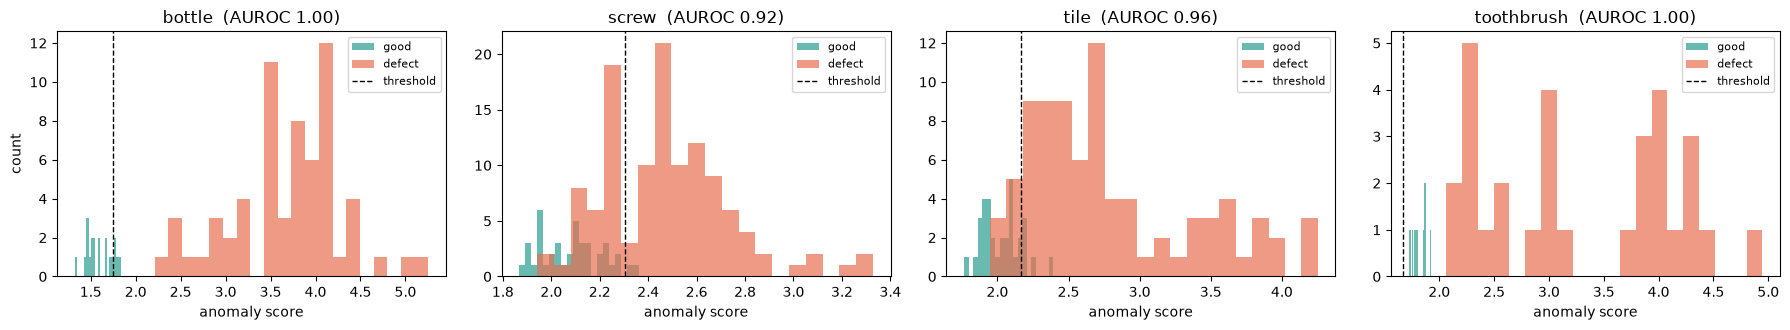

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(18, 3.4))
for ax, part in zip(axes, PARTS):
    r = results[part]
    s, y = r["scores"], r["y_true"]
    ax.hist(s[y == 0], bins=20, alpha=0.7, label="good", color="#2a9d8f")
    ax.hist(s[y == 1], bins=20, alpha=0.7, label="defect", color="#e76f51")
    ax.axvline(r["thresh"], color="k", ls="--", lw=1, label="threshold")
    ax.set_title(f"{part}  (AUROC {r['auroc']:.2f})")
    ax.set_xlabel("anomaly score"); ax.legend(fontsize=8)
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()

## 7. Localization heatmaps — *where* is the defect?

PatchCore's patch distances form an **anomaly map**. Below, for each part, we overlay the map on a
defective test image. This is the payoff of going patch-level: it works regardless of the part's
orientation and points at the defect. Look at `screw` in particular — a pixel autoencoder could not
do this.

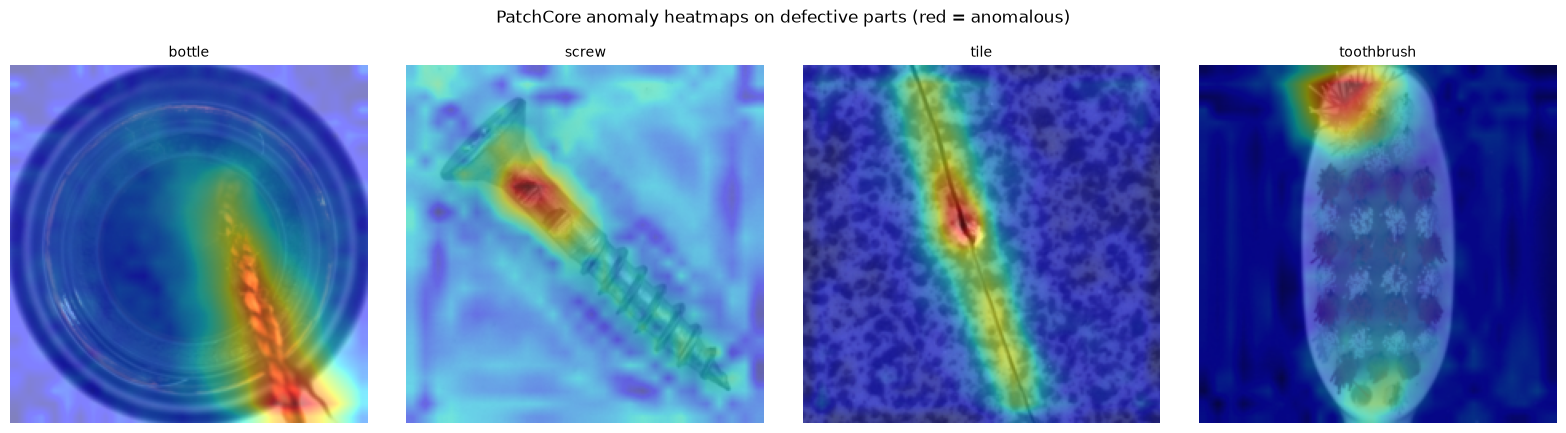

In [8]:
from PIL import Image as PILImage

def show_map(ax, part, path):
    bank_t = models[part]["bank_t"]
    _, maps = image_scores(bank_t, [path], grid=True)
    amap = maps[0]
    img = preprocess.transforms[1](preprocess.transforms[0](PILImage.open(path).convert("RGB")))  # resize+crop
    up = np.array(PILImage.fromarray(amap).resize(img.size, PILImage.BILINEAR))
    ax.imshow(img); ax.imshow(up, cmap="jet", alpha=0.5); ax.axis("off")
    ax.set_title(f"{part}", fontsize=10)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, part in zip(axes, PARTS):
    defect_paths = list_images(ROOT / part / "test" / "defect")
    # pick the highest-scoring (most anomalous) defect image for a clear illustration
    s = image_scores(models[part]["bank_t"], defect_paths)
    show_map(ax, part, defect_paths[int(np.argmax(s))])
plt.suptitle("PatchCore anomaly heatmaps on defective parts (red = anomalous)", y=1.02)
plt.tight_layout(); plt.show()

## Summary

- The old global-embedding / autoencoder idea is gone. This notebook is a **PatchCore** pipeline:
  frozen ResNet-18 patch features → greedy-coreset memory bank of *good* patches → patch nearest-
  neighbour scoring.
- Four independent single-class models are trained (one per part), saved to
  `models/<part>_patchcore.npy`.
- Because scoring is **patch-local**, it is robust to parts with **no fixed orientation** (`screw`):
  a rotated good part's patches still find good matches, so no alignment or autoencoder is needed.
- The heatmaps localise the defect — impossible with an alignment-dependent pixel autoencoder.

**Possible next steps:** WideResNet-50 backbone for a few more AUROC points, per-part threshold tuning
on a held-out split, and pixel-level AUROC using the (removed) ground-truth masks if you want to
measure localisation quality.